In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import datetime as dt

In [3]:
df = pd.read_csv('/content/online_retail_II.xlsx - Year 2009-2010.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [22]:
df["InvoiceDate"] = pd.to_datetime(df['InvoiceDate'])
df["Customer ID"] = df["Customer ID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [5]:

# Check for null values
print(df.isnull().sum())

# Get the shape of the DataFrame
print("\nShape of the DataFrame:")
print(df.shape)

# Get the data types of each column
print("\nData types of each column:")
print(df.dtypes)

# Summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())

# Unique values in each column
for col in df.columns:
    print(f"\nUnique values in column '{col}': {df[col].nunique()}")


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Shape of the DataFrame:
(525461, 8)

Data types of each column:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

Summary statistics:
            Quantity          Price    Customer ID
count  525461.000000  525461.000000  417534.000000
mean       10.337667       4.688834   15360.645478
std       107.424110     146.126914    1680.811316
min     -9600.000000  -53594.360000   12346.000000
25%         1.000000       1.250000   13983.000000
50%         3.000000       2.100000   15311.000000
75%        10.000000       4.210000   16799.000000
max     19152.000000   25111.090000   18287.000000

Unique values in column 'Invoice': 28816

Unique values in column '

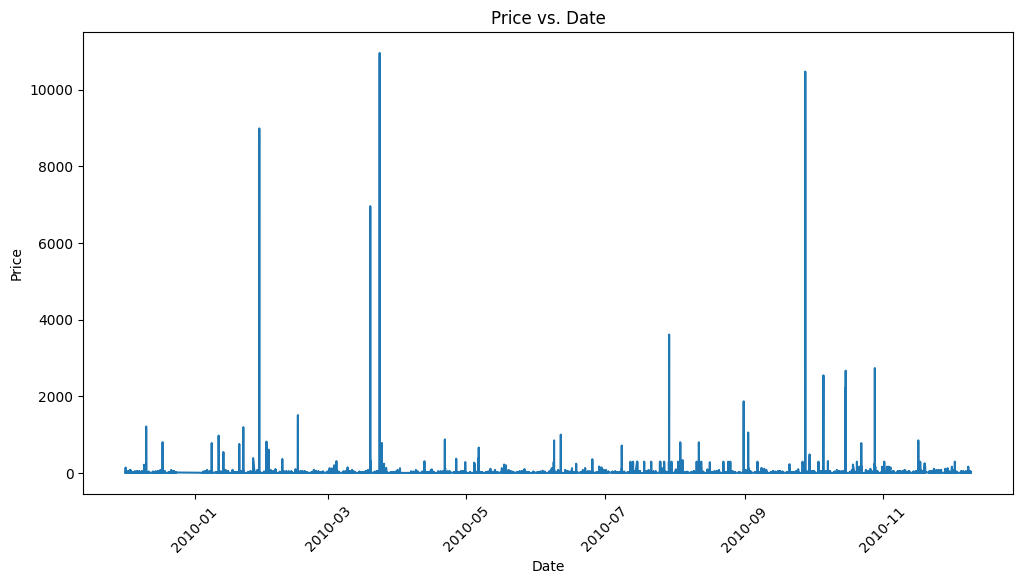

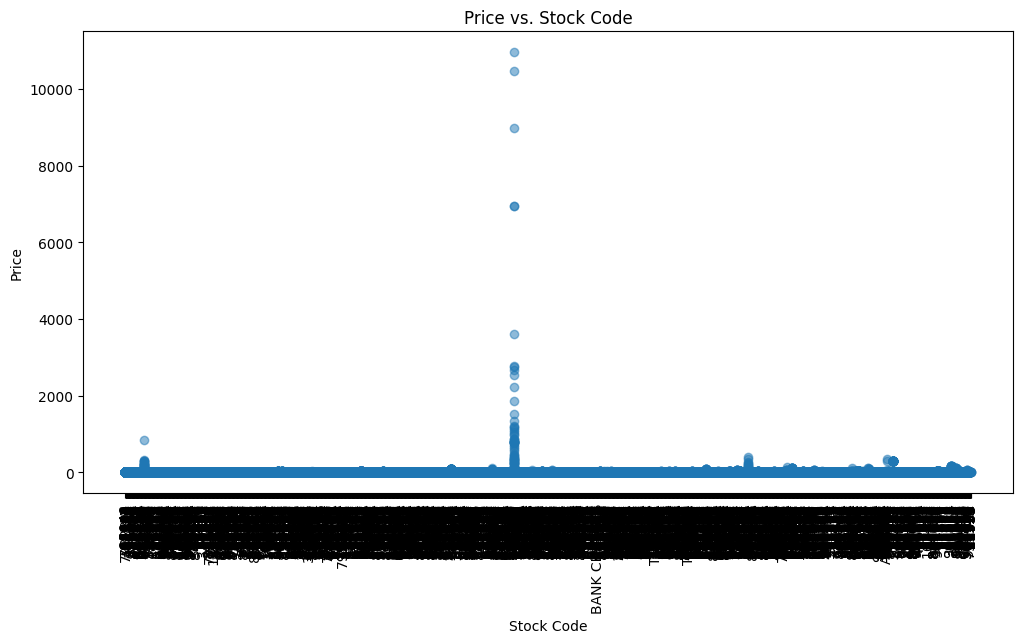

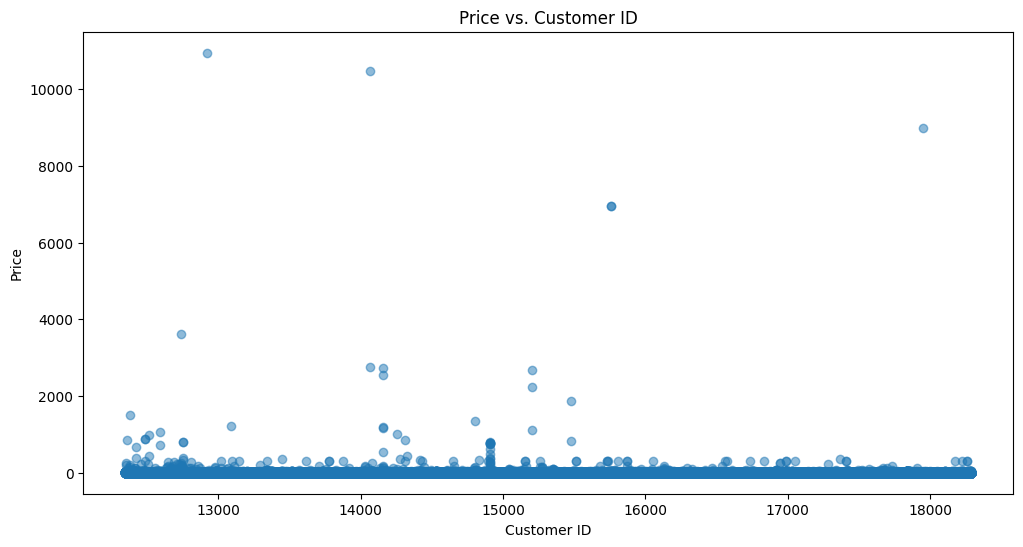

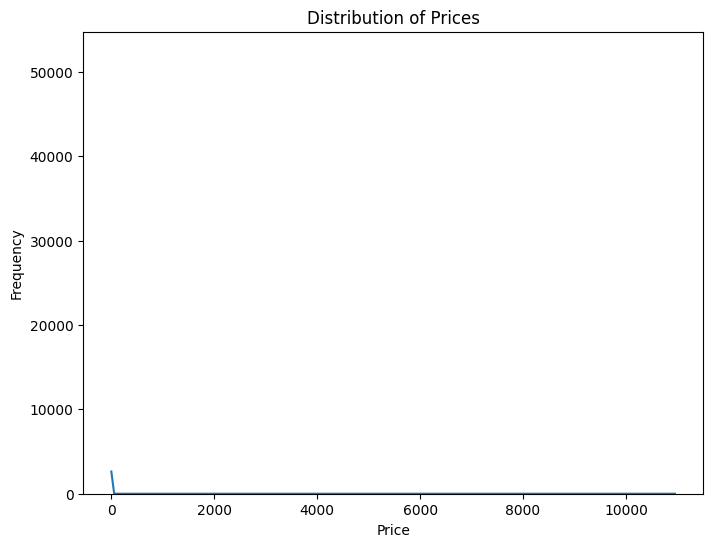

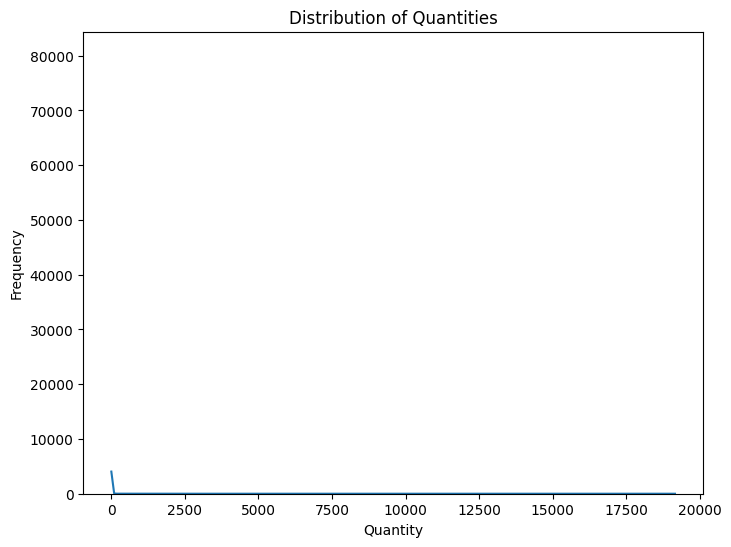

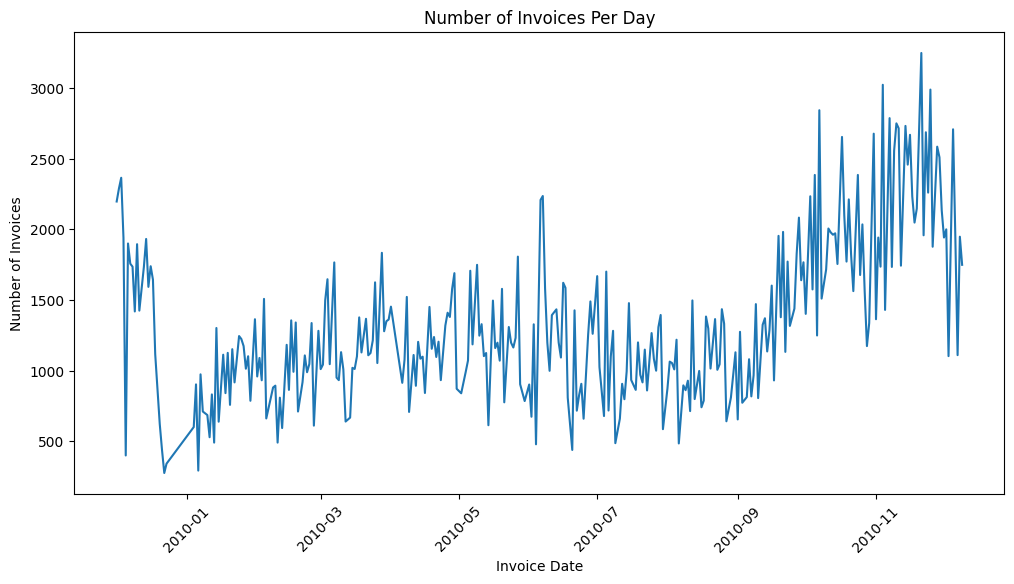

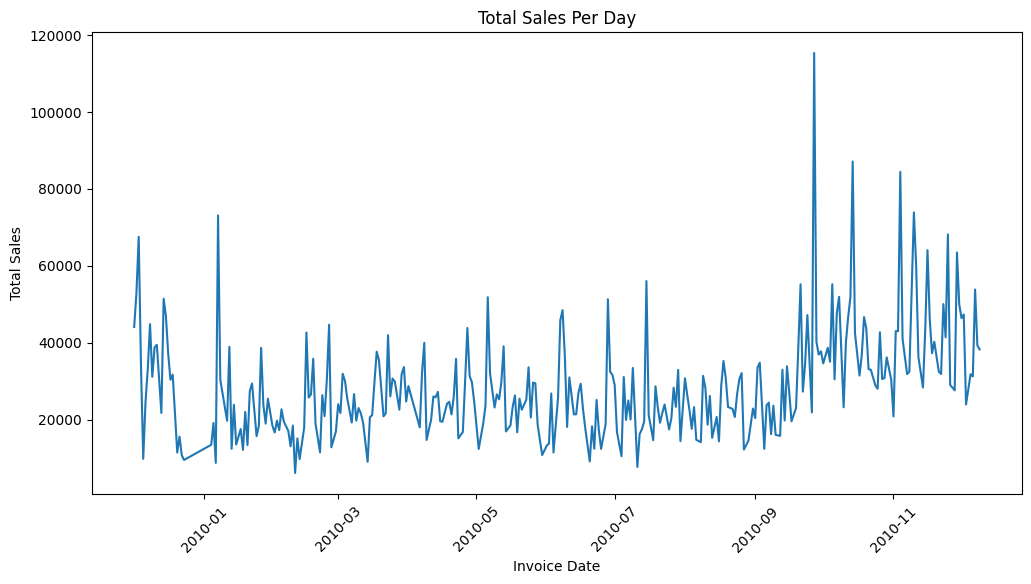

In [37]:


# 1. Price vs. Date
plt.figure(figsize=(12, 6))
plt.plot(df['InvoiceDate'], df['Price'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price vs. Date')
plt.xticks(rotation=45)
plt.show()


# 2. Price vs. StockCode (Scatter Plot for many StockCodes)
plt.figure(figsize=(12, 6))
plt.scatter(df['StockCode'], df['Price'], alpha=0.5)  # alpha for transparency
plt.xlabel('Stock Code')
plt.ylabel('Price')
plt.title('Price vs. Stock Code')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.show()


# 3. Customer ID vs. Price
plt.figure(figsize=(12, 6))
plt.scatter(df['Customer ID'], df['Price'], alpha=0.5)
plt.xlabel('Customer ID')
plt.ylabel('Price')
plt.title('Price vs. Customer ID')
plt.show()

# 4. Price distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], kde=True)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Prices")
plt.show()


# 5. Quantity distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Quantity'], kde=True)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantities")
plt.show()


# 6. Number of Invoices per day
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # Ensure InvoiceDate is datetime
df['InvoiceDay'] = df['InvoiceDate'].dt.date
plt.figure(figsize=(12, 6))
df.groupby('InvoiceDay')['Invoice'].count().plot()
plt.xlabel("Invoice Date")
plt.ylabel("Number of Invoices")
plt.title("Number of Invoices Per Day")
plt.xticks(rotation=45)
plt.show()


# 7. Total sales over time
df['Total'] = df['Quantity'] * df['Price']
plt.figure(figsize=(12, 6))
df.groupby('InvoiceDay')['Total'].sum().plot()
plt.xlabel("Invoice Date")
plt.ylabel("Total Sales")
plt.title("Total Sales Per Day")
plt.xticks(rotation=45)
plt.show()


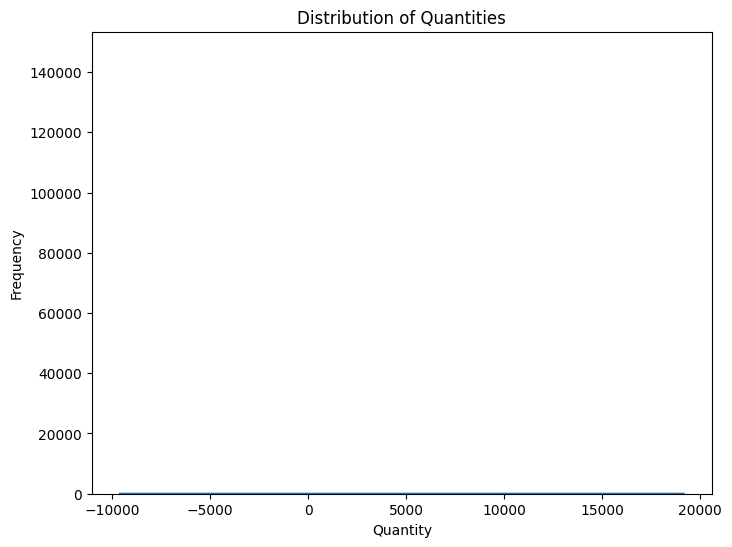

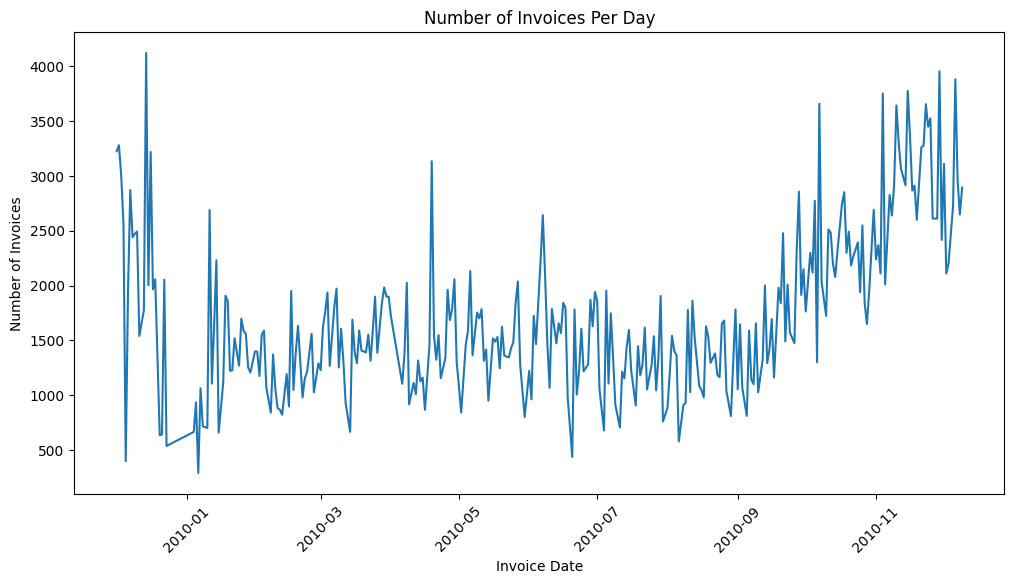

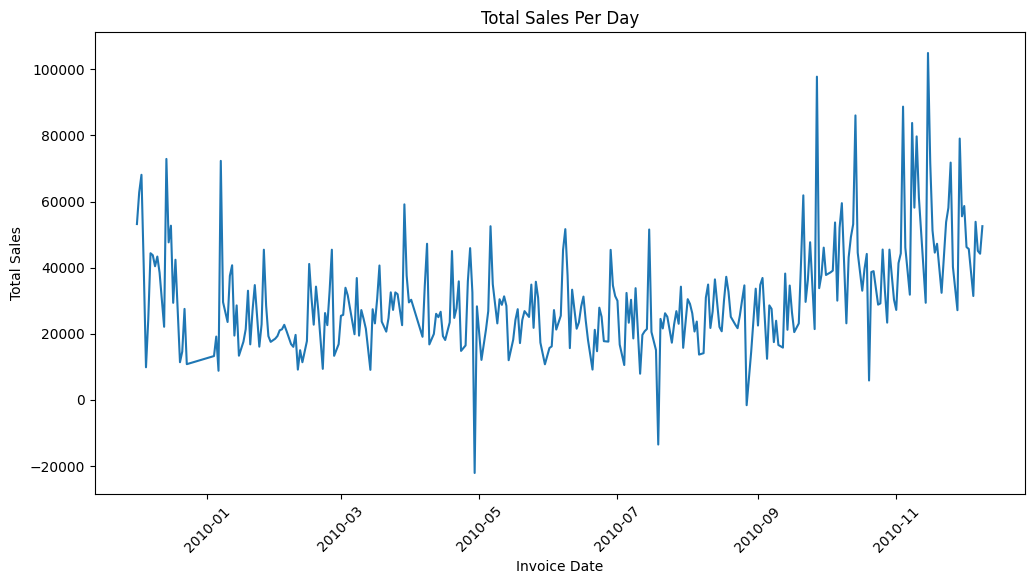

In [8]:
# plt.figure(figsize=(8, 6))
# sns.histplot(df['Price'], kde=True)
# plt.xlabel("Price")
# plt.ylabel("Frequency")
# plt.title("Distribution of Prices")
# plt.show()


# 5. Quantity distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Quantity'], kde=True)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantities")
plt.show()


# 6. Number of Invoices per day
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # Ensure InvoiceDate is datetime
df['InvoiceDay'] = df['InvoiceDate'].dt.date
plt.figure(figsize=(12, 6))
df.groupby('InvoiceDay')['Invoice'].count().plot()
plt.xlabel("Invoice Date")
plt.ylabel("Number of Invoices")
plt.title("Number of Invoices Per Day")
plt.xticks(rotation=45)
plt.show()


# 7. Total sales over time
df['Total'] = df['Quantity'] * df['Price']
plt.figure(figsize=(12, 6))
df.groupby('InvoiceDay')['Total'].sum().plot()
plt.xlabel("Invoice Date")
plt.ylabel("Total Sales")
plt.title("Total Sales Per Day")
plt.xticks(rotation=45)
plt.show()


In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceDay,Total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,30.0


In [10]:
df = df[~df["Invoice"].str.contains("C", na = False)]
df.dropna(inplace = True)

In [12]:
df.shape

(407695, 10)

In [15]:
recent_date = df['InvoiceDate'].max()
print(recent_date)

2010-12-09 20:01:00


In [19]:
#Recency
recency = (recent_date - df.groupby("Customer ID").agg({"InvoiceDate":"max"}))
# Rename column name as Recency
recency.rename(columns = {"InvoiceDate":"Recency"}, inplace = True)
# Change the values to day format
recency_df = recency["Recency"].apply(lambda x: x.days)
recency_df.head()

,Recency
Customer ID,
12346,164
12347,2
12348,73
12349,42
12351,10


In [20]:
#Frequency
frequency_df = df.groupby("Customer ID").agg({"Invoice":"nunique"})
frequency_df.rename(columns = {"Invoice":"Frequency"}, inplace = True)
frequency_df.head()

,Frequency
Customer ID,
12346,11
12347,2
12348,1
12349,3
12351,1


from matplotlib import pyplot as plt
_df_0['Frequency'].plot(kind='hist', bins=20, title='Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Frequency'].plot(kind='line', figsize=(8, 4), title='Frequency')
plt.gca().spines[['top', 'right']].set_visible(False)

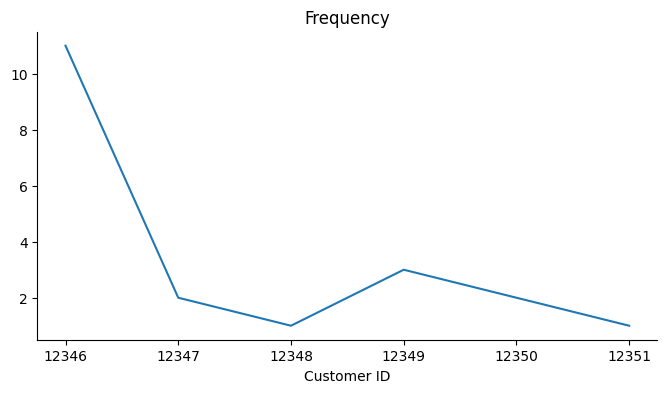

In [24]:
from matplotlib import pyplot as plt
_df_1['Frequency'].plot(kind='line', figsize=(8, 4), title='Frequency')
plt.gca().spines[['top', 'right']].set_visible(False)

In [23]:
monetary_df = df.groupby("Customer ID").agg({"TotalPrice":"sum"})
monetary_df.rename(columns = {"TotalPrice":"Monetary"}, inplace = True)
monetary_df.head()


,Monetary
Customer ID,
12346,372.86
12347,1323.32
12348,222.16
12349,2671.14
12351,300.93


from matplotlib import pyplot as plt
_df_2['Monetary'].plot(kind='hist', bins=20, title='Monetary')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Monetary'].plot(kind='line', figsize=(8, 4), title='Monetary')
plt.gca().spines[['top', 'right']].set_visible(False)

In [26]:
rfm = pd.concat([recency_df, frequency_df, monetary_df], axis = 1)
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,164,11,372.86
12347,2,2,1323.32
12348,73,1,222.16
12349,42,3,2671.14
12351,10,1,300.93


In [27]:
# Dividing the recency values into recency scores such that the lowest recency value as 5 and the highest as 1
# Dividing the frequency values into frequency scores such that the lowest frequency value as 1 and the highest as 5
# Dividing the monetary values into monetary scores such that the lowest monetary value as 1 and the highest as 5

rfm["RecencyScore"] = pd.qcut(rfm["Recency"], 5, labels = [5, 4 , 3, 2, 1])
rfm["FrequencyScore"]= pd.qcut(rfm["Frequency"].rank(method="first"),5, labels=[1,2,3,4,5])
rfm["MonetaryScore"] = pd.qcut(rfm['Monetary'], 5, labels = [1, 2, 3, 4, 5])

In [28]:
rfm["RFM_SCORE"] = (rfm['RecencyScore'].astype(str) +
                    rfm['FrequencyScore'].astype(str) +
                    rfm['MonetaryScore'].astype(str))

In [31]:
# Customers with highest scores
rfm[rfm["RFM_SCORE"]=="555"].head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
Customer ID,,,,,,,
12415,10,7,19543.84,5,5,5,555
12431,8,13,4370.52,5,5,5,555
12471,9,49,20139.74,5,5,5,555
12472,4,13,11308.48,5,5,5,555
12474,13,13,5048.66,5,5,5,555


In [32]:
# Customers with worst scores
rfm[rfm["RFM_SCORE"]=="111"].head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
Customer ID,,,,,,,
12362,373,1,130.00,1,1,1,111
12392,226,1,234.75,1,1,1,111
12404,317,1,63.24,1,1,1,111
12416,291,1,202.56,1,1,1,111
12466,317,1,56.73,1,1,1,111


In [33]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

In [34]:
# Recency and Frequency scores are turned into string format, combined and assigned to Segment
rfm['Segment'] = rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str)
# Segments are changed with the definitons of seg_map
rfm['Segment'] = rfm['Segment'].replace(seg_map, regex=True)

In [35]:
rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE,Segment
Customer ID,,,,,,,,
12346,164,11,372.86,2,5,2,252,Can't Loose
12347,2,2,1323.32,5,2,4,524,Potential Loyalists
12348,73,1,222.16,2,1,1,211,Hibernating
12349,42,3,2671.14,3,3,5,335,Need Attention
12351,10,1,300.93,5,1,2,512,New Customers


In [36]:
# Mean, median, count statistics of different segments
rfm[["Segment","Recency","Frequency", "Monetary"]].groupby("Segment").agg(["mean","median","count"])

Recency               Frequency               \
                           mean median count       mean median count   
Segment                                                                
About to Sleep        52.819242   52.0   343   1.201166    1.0   343   
At Risk              151.155483  130.0   611   3.073650    3.0   611   
Can't Loose          123.116883  108.0    77   9.116883    7.0    77   
Champions              6.119155    6.0   663  12.553544    8.0   663   
Hibernating          213.056047  212.0  1017   1.125860    1.0  1017   
Loyal Customers       35.287062   30.0   742   6.830189    5.0   742   
Need Attention        52.265700   52.0   207   2.449275    2.0   207   
New Customers          7.580000    7.5    50   1.000000    1.0    50   
Potential Loyalists   17.793037   18.0   517   2.017408    2.0   517   
Promising             24.747126   24.0    87   1.000000    1.0    87   

                        Monetary                  
                            mean    median count  
Segment                                           
About to Sleep        441.320000   317.760   343  
At Risk              1188.878316   760.190   611  
Can't Loose          4099.450000  2322.590    77  
Champions            6852.264167  2508.320   663  
Hibernating           403.183386   250.260  1017  
Loyal Customers      2746.067353  1821.385   742  
Need Attention       1060.357005   742.900   207  
New Customers         386.199200   258.825    50  
Potential Loyalists   729.510986   524.650   517  
Promising             367.086782   293.740    87